<a href="https://colab.research.google.com/github/roberto-brito/comeco/blob/master/14112025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**BASE RH COM PANDAS**

In [1]:
import pandas as pd


In [4]:
rh = pd.read_excel('/content/base_rh10.xlsx')
rh.head()

,ID_CANDIDATO,DATA_APLICACAO,VAGA,SENIORIDADE,CIDADE,FONTE,STATUS_FINAL,ENTREVISTAS,SCORE_TECNICO,EXPECT_SALARIAL,TEMPO_PROCESSO_DIAS
0,C00683,2024-04-12,Product Owner,Pleno,Belo Horizonte,Indeed,Aprovado,0,93.9,8958.86,16.0
1,C00684,2024-12-14,Analista de Dados,Pleno,Porto Alegre,Site da Empresa,Reprovado,4,65.3,9885.61,35.0
2,C00685,2024-09-27,Desenvolvedor Backend,Júnior,Fortaleza,Indicação,Aprovado,0,77.0,5958.46,12.0
3,C00686,2024-04-16,Desenvolvedor Frontend,Júnior,Rio de Janeiro,Site da Empresa,Reprovado,1,NaN,5719.32,6.0
4,C00687,2024-03-12,Analista de Dados,Pleno,Recife,LinkedIn,Aprovado,5,75.2,11923.22,15.0


In [5]:
rh.describe() #mostra dados estatísticos da base

,DATA_APLICACAO,ENTREVISTAS,TEMPO_PROCESSO_DIAS
count,1224,1224.000000,1183.000000
mean,2024-07-02 08:25:52.941176320,2.928105,30.022823
min,2024-01-01 00:00:00,0.000000,0.000000
25%,2024-04-07 00:00:00,1.000000,15.000000
50%,2024-06-30 00:00:00,3.000000,30.000000
75%,2024-10-03 06:00:00,5.000000,45.000000
max,2024-12-30 00:00:00,6.000000,60.000000
std,NaN,2.046011,17.319247


In [30]:
rh.dtypes #mostra os tipos de dados da coluna

,0
ID_CANDIDATO,object
DATA_APLICACAO,datetime64[ns]
VAGA,object
SENIORIDADE,object
CIDADE,object
FONTE,object
STATUS_FINAL,object
ENTREVISTAS,int64
SCORE_TECNICO,object
EXPECT_SALARIAL,object


In [7]:
rh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_CANDIDATO         1224 non-null   object        
 1   DATA_APLICACAO       1224 non-null   datetime64[ns]
 2   VAGA                 1224 non-null   object        
 3   SENIORIDADE          1224 non-null   object        
 4   CIDADE               1186 non-null   object        
 5   FONTE                1186 non-null   object        
 6   STATUS_FINAL         1185 non-null   object        
 7   ENTREVISTAS          1224 non-null   int64         
 8   SCORE_TECNICO        1183 non-null   object        
 9   EXPECT_SALARIAL      1185 non-null   object        
 10  TEMPO_PROCESSO_DIAS  1183 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(8)
memory usage: 105.3+ KB


In [34]:
rh.isna().sum() #mostra a quantidade de dados nulos

,0
ID_CANDIDATO,0
DATA_APLICACAO,0
VAGA,0
SENIORIDADE,0
CIDADE,0
FONTE,0
STATUS_FINAL,0
SCORE_TECNICO,0
EXPECT_SALARIAL,0
TEMPO_PROCESSO_DIAS,0


In [11]:
rh['CIDADE'] = rh['CIDADE'].fillna('Não informado') #onde na coluna cidade tem valor vazio, vai colocar o texto Não informado


In [24]:
print(rh.to_string()) #mostra a base

     ID_CANDIDATO DATA_APLICACAO                    VAGA SENIORIDADE          CIDADE            FONTE   STATUS_FINAL  ENTREVISTAS        SCORE_TECNICO      EXPECT_SALARIAL  TEMPO_PROCESSO_DIAS
0          C00683     2024-04-12           Product Owner       Pleno  Belo Horizonte           Indeed       Aprovado            0                 93.9              8958.86                 16.0
1          C00684     2024-12-14       Analista de Dados       Pleno    Porto Alegre  Site da Empresa      Reprovado            4                 65.3              9885.61                 35.0
2          C00685     2024-09-27   Desenvolvedor Backend      Júnior       Fortaleza        Indicação       Aprovado            0                 77.0              5958.46                 12.0
3          C00686     2024-04-16  Desenvolvedor Frontend      Júnior  Rio de Janeiro  Site da Empresa      Reprovado            1        Não informado              5719.32                  6.0
4          C00687     2024-03-12   

In [14]:
rh['FONTE'] = rh['FONTE'].fillna('Indefinida') #onde na coluna cidade tem valor vazio, vai colocar o texto Não informado

In [18]:
rh['STATUS_FINAL'] = rh['STATUS_FINAL'].fillna('Não informado') #onde na coluna cidade tem valor vazio, vai colocar o texto Não informado

In [22]:
# rh['SCORE_TECNICO'] = rh['SCORE_TECNICO'].fillna(rh['SCORE_TECNICO'].median()) # preencher com mediana
rh['SCORE_TECNICO'] = rh['SCORE_TECNICO'].fillna(('Não informado'))

In [25]:
rh['EXPECT_SALARIAL'] = rh['EXPECT_SALARIAL'].fillna(('Nada consta'))

In [29]:
rh.duplicated().sum() #mostra a quantidade de dados duplicados

np.int64(0)

In [28]:
rh = rh.drop_duplicates().reset_index(drop = True) #exclui os dados duplicados

In [31]:
rh['TEMPO_PROCESSO_DIAS'] = rh['TEMPO_PROCESSO_DIAS'].fillna(rh['TEMPO_PROCESSO_DIAS'].median()) # preencher com mediana

In [33]:
rh.drop(columns=['ENTREVISTAS'], inplace = True) # apaga uma coluna, inclusive na base

#**Gráficos**

##**Barras horizontais - candidatos por VAGA**

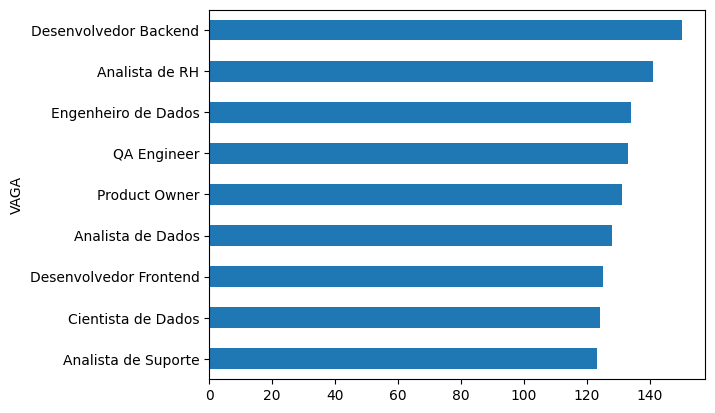

In [36]:
import matplotlib.pyplot as plt
serie = rh['VAGA'].value_counts().sort_values()
ax = serie.plot(kind='barh')
plt.label = ('Candidatos')
plt.ylabel = ('Vagas')
plt.title = ('Candidatos por Vaga')
plt.show()